# Traffix.id — YOLOv8 Traffic Feature Extraction Pipeline

**Project:** Traffix.id  
**Dataset:** Traffic Road Object Detection Dataset (Kaggle)  
**Model:** YOLOv8 (Ultralytics)  

---

### Pipeline Overview

1. Install Dependencies
2. Import Library & Global Configuration
3. GPU Check
4. Download Kaggle Dataset
5. Dataset Inspection
6. Generate YOLO data.yaml
7. Train YOLOv8
8. Validate YOLOv8
9. Compute Accuracy, Precision, Recall, F1-score
10. Inference on All Images
11. Traffic Feature Extraction Per-Zona
12. Export traffic_features.csv
13. Detection Visualization
14. Traffic Feature Dashboard
15. Summary of Outputs

## Section 1 — Install Dependencies

In [1]:
# Install all required packages
!pip install -q ultralytics kagglehub opencv-python-headless pandas matplotlib scikit-learn PyYAML
print("All dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.3 MB/s eta 0:00:00
All dependencies installed.


## Section 2 — Import Library & Global Configuration

In [2]:
import os
import glob
import shutil
import random
import warnings
import yaml

import numpy as np
import pandas as pd
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from pathlib import Path
from sklearn.metrics import confusion_matrix

import torch
from ultralytics import YOLO

warnings.filterwarnings("ignore")

# ── Global Configuration ──────────────────────────────────────────────────────
CONFIG = {
    # Training
    "MODEL_WEIGHTS"    : "yolov8n.pt",   # nano for speed; swap to yolov8s.pt / yolov8m.pt as needed
    "EPOCHS"           : 30,
    "IMGSZ"            : 640,
    "BATCH"            : 16,
    "PATIENCE"         : 10,
    "WORKERS"          : 2,
    "PROJECT_NAME"     : "traffix_id",
    "EXP_NAME"         : "yolov8_traffic",

    # Zone thresholds (fraction of image width)
    "ZONE_LEFT_MAX"    : 0.33,
    "ZONE_CENTER_MAX"  : 0.67,

    # Feature extraction
    "IOU_THRESHOLD"    : 0.50,           # for TP/FP/FN computation
    "CONF_THRESHOLD"   : 0.25,           # inference confidence

    # Paths
    "DATA_YAML"        : "data.yaml",
    "OUTPUT_CSV"       : "traffic_features.csv",
    "VIZ_PNG"          : "detection_visualization.png",
    "DASH_PNG"         : "traffic_feature_dashboard.png",
}

ZONE_LABELS = ["LEFT", "CENTER", "RIGHT"]

print("Libraries imported.")
print("Global configuration set.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported.
Global configuration set.


## Section 3 — GPU Check

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
print(f"Device selected  : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU name         : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory (GB)  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print("WARNING — No GPU detected. Training will run on CPU and may be slow.")
    print("Go to Runtime > Change runtime type > Hardware accelerator > GPU.")

PyTorch version  : 2.11.0+cu128
CUDA available   : True
Device selected  : cuda
GPU name         : Tesla T4
GPU memory (GB)  : 15.64


## Section 4 — Download Kaggle Dataset

In [4]:
import kagglehub

print("Downloading dataset from Kaggle...")
DATASET_PATH = kagglehub.dataset_download(
    "boukraailyesali/traffic-road-object-detection-dataset-using-yolo"
)
DATASET_PATH = Path(DATASET_PATH)
print(f"Dataset downloaded to: {DATASET_PATH}")

100%|██████████| 380M/380M [00:22<00:00, 17.9MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/boukraailyesali/traffic-road-object-detection-dataset-using-yolo/versions/1


## Section 5 — Dataset Inspection

In [5]:
def find_dataset_root(base: Path) -> Path:
    for root, dirs, files in os.walk(base):
        root_p = Path(root)
        has_train = (root_p / "train" / "images").exists()
        has_val   = (root_p / "val"   / "images").exists()
        if has_train and has_val:
            return root_p
    return base


DATASET_ROOT = find_dataset_root(DATASET_PATH)
print(f"Dataset root identified: {DATASET_ROOT}")

# ── Expected paths ────────────────────────────────────────────────────────────
TRAIN_IMG_DIR  = DATASET_ROOT / "train" / "images"
TRAIN_LBL_DIR  = DATASET_ROOT / "train" / "labels"
VAL_IMG_DIR    = DATASET_ROOT / "val"   / "images"
VAL_LBL_DIR    = DATASET_ROOT / "val"   / "labels"
CLASSES_FILE   = DATASET_ROOT / "classes.txt"

# ── Validation ────────────────────────────────────────────────────────────────
checks = {
    "train/images" : TRAIN_IMG_DIR,
    "train/labels" : TRAIN_LBL_DIR,
    "val/images"   : VAL_IMG_DIR,
    "val/labels"   : VAL_LBL_DIR,
    "classes.txt"  : CLASSES_FILE,
}

all_ok = True
for name, path in checks.items():
    exists = path.exists()
    status = "OK" if exists else "MISSING"
    if not exists:
        all_ok = False
    print(f"  {status:8s}  {name}")

if not all_ok:
    print("WARNING — Some expected paths are missing. Inspect DATASET_ROOT above.")

# ── Class names ───────────────────────────────────────────────────────────────
if CLASSES_FILE.exists():
    CLASS_NAMES = [l.strip() for l in CLASSES_FILE.read_text().splitlines() if l.strip()]
else:
    # Fallback: derive from data.yaml if present
    yaml_candidates = list(DATASET_ROOT.glob("*.yaml"))
    if yaml_candidates:
        with open(yaml_candidates[0]) as f:
            _y = yaml.safe_load(f)
        CLASS_NAMES = _y.get("names", [])
    else:
        CLASS_NAMES = ["vehicle"]   # absolute fallback

NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")

# ── Image counts ──────────────────────────────────────────────────────────────
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
train_imgs = [p for p in TRAIN_IMG_DIR.iterdir() if p.suffix.lower() in IMG_EXTS]
val_imgs   = [p for p in VAL_IMG_DIR.iterdir()   if p.suffix.lower() in IMG_EXTS]

print(f"\nTrain images : {len(train_imgs)}")
print(f"Val images   : {len(val_imgs)}")
print(f"Total images : {len(train_imgs) + len(val_imgs)}")

Dataset root identified: /root/.cache/kagglehub/datasets/boukraailyesali/traffic-road-object-detection-dataset-using-yolo/versions/1
  OK        train/images
  OK        train/labels
  OK        val/images
  OK        val/labels
  OK        classes.txt

Classes (1): ['car']

Train images : 399
Val images   : 100
Total images : 499


## Section 6 — Generate YOLO data.yaml

In [6]:
data_yaml = {
    "path" : str(DATASET_ROOT),
    "train": str(TRAIN_IMG_DIR),
    "val"  : str(VAL_IMG_DIR),
    "nc"   : NUM_CLASSES,
    "names": CLASS_NAMES,
}

DATA_YAML_PATH = Path(CONFIG["DATA_YAML"])
with open(DATA_YAML_PATH, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f"data.yaml written to: {DATA_YAML_PATH.resolve()}")
print("---")
print(DATA_YAML_PATH.read_text())

data.yaml written to: /content/data.yaml
---
path: /root/.cache/kagglehub/datasets/boukraailyesali/traffic-road-object-detection-dataset-using-yolo/versions/1
train: /root/.cache/kagglehub/datasets/boukraailyesali/traffic-road-object-detection-dataset-using-yolo/versions/1/train/images
val: /root/.cache/kagglehub/datasets/boukraailyesali/traffic-road-object-detection-dataset-using-yolo/versions/1/val/images
nc: 1
names:
- car



## Section 7 — Train YOLOv8

In [7]:
model = YOLO(CONFIG["MODEL_WEIGHTS"])

print(f"Starting YOLOv8 training — {CONFIG['EPOCHS']} epochs, device={DEVICE}")

train_results = model.train(
    data     = str(DATA_YAML_PATH),
    epochs   = CONFIG["EPOCHS"],
    imgsz    = CONFIG["IMGSZ"],
    batch    = CONFIG["BATCH"],
    patience = CONFIG["PATIENCE"],
    workers  = CONFIG["WORKERS"],
    device   = DEVICE,
    project  = CONFIG["PROJECT_NAME"],
    name     = CONFIG["EXP_NAME"],
    exist_ok = True,
    verbose  = True,
)

# Locate best weights
BEST_PT = Path(CONFIG["PROJECT_NAME"]) / CONFIG["EXP_NAME"] / "weights" / "best.pt"
if not BEST_PT.exists():
    # Fallback search
    candidates = list(Path(CONFIG["PROJECT_NAME"]).rglob("best.pt"))
    if candidates:
        BEST_PT = candidates[0]

print(f"Training complete. Best weights: {BEST_PT}")

Starting YOLOv8 training — 30 epochs, device=cuda
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_traffic, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

## Section 8 — Validate YOLOv8

In [8]:
BEST_PT = Path("/content/runs/detect") / CONFIG["PROJECT_NAME"] / CONFIG["EXP_NAME"] / "weights" / "best.pt"
model_best = YOLO(str(BEST_PT))

print("Running validation on val set...")
val_results = model_best.val(
    data    = str(DATA_YAML_PATH),
    imgsz   = CONFIG["IMGSZ"],
    device  = DEVICE,
    verbose = True,
)

# Extract built-in YOLO metrics
MAP50     = float(val_results.box.map50)    if hasattr(val_results.box, "map50")    else float(val_results.box.map[0])
MAP50_95  = float(val_results.box.map)      if hasattr(val_results.box, "map")      else 0.0
YOLO_P    = float(val_results.box.mp)       if hasattr(val_results.box, "mp")       else 0.0
YOLO_R    = float(val_results.box.mr)       if hasattr(val_results.box, "mr")       else 0.0

print(f"\nYOLO Validation Metrics")
print(f"  mAP50    : {MAP50:.4f}")
print(f"  mAP50-95 : {MAP50_95:.4f}")
print(f"  Precision: {YOLO_P:.4f}")
print(f"  Recall   : {YOLO_R:.4f}")

Running validation on val set...
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4400.1±1778.2 MB/s, size: 770.4 KB)
val: Scanning /root/.cache/kagglehub/datasets/boukraailyesali/traffic-road-object-detection-dataset-using-yolo/versions/1/val/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 41.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.0it/s 3.6s
                   all        100        493      0.955      0.813      0.926      0.532
Speed: 3.8ms preprocess, 6.0ms inference, 0.0ms loss, 4.7ms postprocess per image
Results saved to /content/runs/detect/val

YOLO Validation Metrics
  mAP50    : 0.9256
  mAP50-95 : 0.5324
  Precision: 0.9547
  Recall   : 0.8129


## Section 9 — Compute Accuracy, Precision, Recall, F1-score

In [9]:
def xywhn_to_xyxy(box, img_w, img_h):
    """Convert YOLO normalised cx cy w h to absolute x1 y1 x2 y2."""
    cx, cy, w, h = box
    x1 = (cx - w / 2) * img_w
    y1 = (cy - h / 2) * img_h
    x2 = (cx + w / 2) * img_w
    y2 = (cy + h / 2) * img_h
    return np.array([x1, y1, x2, y2])


def compute_iou(boxA, boxB):
    """Compute IoU between two boxes in xyxy format."""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0


def load_gt_boxes(label_path, img_w, img_h):
    """Load ground-truth boxes from a YOLO .txt label file."""
    boxes = []
    if not Path(label_path).exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(parts[0])
            xyxy = xywhn_to_xyxy([float(x) for x in parts[1:5]], img_w, img_h)
            boxes.append({"cls": cls, "box": xyxy})
    return boxes

def evaluate_detections(img_paths, label_dir, model, iou_thresh=0.5, conf_thresh=0.25):
    TP_total = FP_total = FN_total = 0
    all_preds = {}   # image_stem -> list of pred dicts

    label_dir = Path(label_dir)

    for img_path in img_paths:
        img_path = Path(img_path)
        stem = img_path.stem

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        # Ground truth
        lbl_file = label_dir / (stem + ".txt")
        gt_boxes = load_gt_boxes(lbl_file, w, h)

        # Predictions
        results = model.predict(
            source=str(img_path),
            conf=conf_thresh,
            device=DEVICE,
            verbose=False,
        )
        pred_boxes = []
        if results and results[0].boxes is not None:
            for box in results[0].boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                cls  = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                pred_boxes.append({"cls": cls, "box": xyxy, "conf": conf})

        all_preds[stem] = pred_boxes

        # Match preds to GT
        matched_gt = set()
        matched_pred = set()

        for pi, pred in enumerate(pred_boxes):
            best_iou  = 0.0
            best_gi   = -1
            for gi, gt in enumerate(gt_boxes):
                if gi in matched_gt:
                    continue
                iou = compute_iou(pred["box"], gt["box"])
                if iou > best_iou:
                    best_iou = iou
                    best_gi  = gi
            if best_iou >= iou_thresh and best_gi >= 0:
                TP_total   += 1
                matched_gt.add(best_gi)
                matched_pred.add(pi)
            else:
                FP_total += 1

        FN_total += len(gt_boxes) - len(matched_gt)

    return TP_total, FP_total, FN_total, all_preds

# ── Run evaluation on validation set ─────────────────────────────────────────
print("Computing TP / FP / FN on validation set (IoU >= 0.50)...")

TP, FP, FN, VAL_PREDS = evaluate_detections(
    img_paths    = val_imgs,
    label_dir    = VAL_LBL_DIR,
    model        = model_best,
    iou_thresh   = CONFIG["IOU_THRESHOLD"],
    conf_thresh  = CONFIG["CONF_THRESHOLD"],
)

PRECISION = TP / (TP + FP)       if (TP + FP)       > 0 else 0.0
RECALL    = TP / (TP + FN)       if (TP + FN)       > 0 else 0.0
F1        = (2 * PRECISION * RECALL / (PRECISION + RECALL)
             if (PRECISION + RECALL) > 0 else 0.0)
ACCURACY  = TP / (TP + FP + FN)  if (TP + FP + FN)  > 0 else 0.0

METRIC_DICT = {
    "TP"       : TP,
    "FP"       : FP,
    "FN"       : FN,
    "Accuracy" : round(ACCURACY,  4),
    "Precision": round(PRECISION, 4),
    "Recall"   : round(RECALL,    4),
    "F1-score" : round(F1,        4),
    "mAP50"    : round(MAP50,     4),
    "mAP50-95" : round(MAP50_95,  4),
}

print("\n--- Evaluation Results (Validation Set) ---")
for k, v in METRIC_DICT.items():
    print(f"  {k:12s}: {v}")

Computing TP / FP / FN on validation set (IoU >= 0.50)...

--- Evaluation Results (Validation Set) ---
  TP          : 436
  FP          : 67
  FN          : 57
  Accuracy    : 0.7786
  Precision   : 0.8668
  Recall      : 0.8844
  F1-score    : 0.8755
  mAP50       : 0.9256
  mAP50-95    : 0.5324


## Section 10 — Inference on All Images

In [10]:
def run_inference_all(img_paths, model, conf_thresh=0.25):
    results_dict = {}
    total = len(img_paths)
    print(f"Running inference on {total} images...")

    for idx, img_path in enumerate(img_paths, 1):
        img_path = Path(img_path)
        stem = img_path.stem

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        res = model.predict(
            source  = str(img_path),
            conf    = conf_thresh,
            device  = DEVICE,
            verbose = False,
        )

        boxes = []
        if res and res[0].boxes is not None:
            for box in res[0].boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                boxes.append({
                    "cls"     : int(box.cls[0].item()),
                    "box_xyxy": xyxy,
                    "conf"    : float(box.conf[0].item()),
                })

        results_dict[stem] = {
            "img_path": str(img_path),
            "boxes"   : boxes,
            "img_w"   : w,
            "img_h"   : h,
        }

        if idx % 50 == 0 or idx == total:
            print(f"  Processed {idx}/{total}")

    return results_dict

ALL_IMG_PATHS = train_imgs + val_imgs

ALL_RESULTS = run_inference_all(
    img_paths   = ALL_IMG_PATHS,
    model       = model_best,
    conf_thresh = CONFIG["CONF_THRESHOLD"],
)

print(f"\nInference complete. Total images processed: {len(ALL_RESULTS)}")

Running inference on 499 images...
  Processed 50/499
  Processed 100/499
  Processed 150/499
  Processed 200/499
  Processed 250/499
  Processed 300/499
  Processed 350/499
  Processed 400/499
  Processed 450/499
  Processed 499/499

Inference complete. Total images processed: 499


## Section 11 — Traffic Feature Extraction Per-Zona

Each image produces **3 rows** (LEFT, CENTER, RIGHT) in the output CSV.

### Zone Definition
Zones are determined by the centroid x of each bounding box (`cx`):

| Zone   | Condition                        |
|--------|----------------------------------|
| LEFT   | `cx < 0.33 * img_w`              |
| CENTER | `0.33 * img_w <= cx < 0.67 * img_w` |
| RIGHT  | `cx >= 0.67 * img_w`             |

### Features
| Feature             | Description                                              |
|---------------------|----------------------------------------------------------|
| `vehicle_count_1min`| Number of vehicles in zone                              |
| `volume_veh_per_hour`| `vehicle_count_1min * 60`                              |
| `density_percent`   | Total bbox area in zone / zone area * 100               |
| `queue_length_veh`  | Estimated queue (0 if density < 20%, else proportional) |
| `avg_speed_kmh`     | Rule-based speed estimate (high density = low speed). **Estimated value, not ground-truth.** |

In [11]:
def assign_zone(cx, img_w, zone_left_max=0.33, zone_center_max=0.67):
    ratio = cx / img_w
    if ratio < zone_left_max:
        return "LEFT"
    elif ratio < zone_center_max:
        return "CENTER"
    else:
        return "RIGHT"

def zone_area(zone_label, img_w, img_h, zone_left_max=0.33, zone_center_max=0.67):
    """Return pixel area of a zone."""
    if zone_label == "LEFT":
        return zone_left_max * img_w * img_h
    elif zone_label == "CENTER":
        return (zone_center_max - zone_left_max) * img_w * img_h
    else:  # RIGHT
        return (1.0 - zone_center_max) * img_w * img_h

def bbox_area_in_zone(box_xyxy, zone_label, img_w, img_h,
                      zone_left_max=0.33, zone_center_max=0.67):
    """Return overlap area between bbox and zone column."""
    x1b, y1b, x2b, y2b = box_xyxy

    # Zone x boundaries in pixels
    if zone_label == "LEFT":
        zx1, zx2 = 0, zone_left_max * img_w
    elif zone_label == "CENTER":
        zx1, zx2 = zone_left_max * img_w, zone_center_max * img_w
    else:
        zx1, zx2 = zone_center_max * img_w, img_w

    ox1 = max(x1b, zx1)
    ox2 = min(x2b, zx2)
    oy1 = max(y1b, 0)
    oy2 = min(y2b, img_h)

    inter_w = max(0, ox2 - ox1)
    inter_h = max(0, oy2 - oy1)
    return inter_w * inter_h

def estimate_speed(density_percent):
    """
    Rule-based speed estimation (km/h) based on density.
    Note: This is an estimated value, not ground-truth speed.
    """
    if density_percent <= 0:
        return 60.0
    elif density_percent < 10:
        return 55.0
    elif density_percent < 20:
        return 45.0
    elif density_percent < 30:
        return 35.0
    elif density_percent < 50:
        return 20.0
    elif density_percent < 70:
        return 10.0
    else:
        return 5.0

def estimate_queue(density_percent, vehicle_count):
    """
    Estimate number of queued vehicles based on density.
    density < 20% -> queue = 0
    density >= 20% -> proportional to excess density and vehicle count
    """
    if density_percent < 20:
        return 0
    else:
        # Proportional: every 10% above 20% adds ~25% of vehicles to queue
        excess = density_percent - 20
        queue  = int(round(vehicle_count * (excess / 100) * 2.5))
        return min(queue, vehicle_count)

def extract_features_per_zona(all_results, zone_left_max=0.33, zone_center_max=0.67):
    """
    For each image, produce 3 rows: LEFT, CENTER, RIGHT.
    Returns a DataFrame.
    """
    rows = []

    for stem, data in all_results.items():
        img_w  = data["img_w"]
        img_h  = data["img_h"]
        boxes  = data["boxes"]

        # Assign each detection to a zone based on centroid x
        zone_detections = {"LEFT": [], "CENTER": [], "RIGHT": []}
        for det in boxes:
            x1, y1, x2, y2 = det["box_xyxy"]
            cx = (x1 + x2) / 2.0
            z  = assign_zone(cx, img_w, zone_left_max, zone_center_max)
            zone_detections[z].append(det)

        for zone in ZONE_LABELS:
            dets = zone_detections[zone]
            z_area = zone_area(zone, img_w, img_h, zone_left_max, zone_center_max)

            # vehicle_count_1min
            vc = len(dets)

            # density — use overlap area within zone
            total_box_area = 0.0
            for det in dets:
                total_box_area += bbox_area_in_zone(
                    det["box_xyxy"], zone, img_w, img_h,
                    zone_left_max, zone_center_max
                )
            density = (total_box_area / z_area * 100) if z_area > 0 else 0.0
            density = min(density, 100.0)

            # volume, queue, speed
            volume = vc * 60
            queue  = estimate_queue(density, vc)
            speed  = estimate_speed(density)

            rows.append({
                "image"              : stem,
                "approach"           : zone,
                "vehicle_count_1min" : vc,
                "volume_veh_per_hour": volume,
                "queue_length_veh"   : queue,
                "density_percent"    : round(density, 4),
                "avg_speed_kmh"      : speed,
            })

    df = pd.DataFrame(rows, columns=[
        "image", "approach",
        "vehicle_count_1min", "volume_veh_per_hour",
        "queue_length_veh", "density_percent", "avg_speed_kmh",
    ])
    return df

print("Extracting traffic features per zona...")
FEATURE_DF = extract_features_per_zona(
    ALL_RESULTS,
    zone_left_max   = CONFIG["ZONE_LEFT_MAX"],
    zone_center_max = CONFIG["ZONE_CENTER_MAX"],
)

print(f"Feature extraction complete.")
print(f"Total rows: {len(FEATURE_DF)} ({len(FEATURE_DF) // 3} images x 3 zones)")
print("\nSample output:")
print(FEATURE_DF.head(9).to_string(index=False))
print("\nNOTE: avg_speed_kmh is a rule-based estimate, not ground-truth speed.")

Extracting traffic features per zona...
Feature extraction complete.
Total rows: 1497 (499 images x 3 zones)

Sample output:
     image approach  vehicle_count_1min  volume_veh_per_hour  queue_length_veh  density_percent  avg_speed_kmh
frame_0058     LEFT                   5                  300                 0          10.9529           45.0
frame_0058   CENTER                   3                  180                 0           7.0010           55.0
frame_0058    RIGHT                   1                   60                 0           8.0341           55.0
frame_0330     LEFT                   5                  300                 0           8.9446           55.0
frame_0330   CENTER                   5                  300                 0           6.7745           55.0
frame_0330    RIGHT                   0                    0                 0           0.0000           60.0
frame_0052     LEFT                   6                  360                 0          18.4312   

## Section 12 — Export traffic_features.csv

In [12]:
CSV_PATH = Path(CONFIG["OUTPUT_CSV"])
FEATURE_DF.to_csv(CSV_PATH, index=False)

print(f"Saved: {CSV_PATH.resolve()}")
print(f"Shape: {FEATURE_DF.shape}  (rows={FEATURE_DF.shape[0]}, cols={FEATURE_DF.shape[1]})")
print("\nColumn summary:")
print(FEATURE_DF.describe().to_string())

Saved: /content/traffic_features.csv
Shape: (1497, 7)  (rows=1497, cols=7)

Column summary:
       vehicle_count_1min  volume_veh_per_hour  queue_length_veh  density_percent  avg_speed_kmh
count         1497.000000          1497.000000       1497.000000      1497.000000    1497.000000
mean             2.674015           160.440882          0.003340         5.060748      54.759519
std              2.223014           133.380835          0.057716         4.931343       5.171745
min              0.000000             0.000000          0.000000         0.000000      35.000000
25%              0.000000             0.000000          0.000000         0.000000      55.000000
50%              3.000000           180.000000          0.000000         4.514300      55.000000
75%              5.000000           300.000000          0.000000         8.236800      60.000000
max              8.000000           480.000000          1.000000        25.574699      60.000000


## Section 13 — Detection Visualization

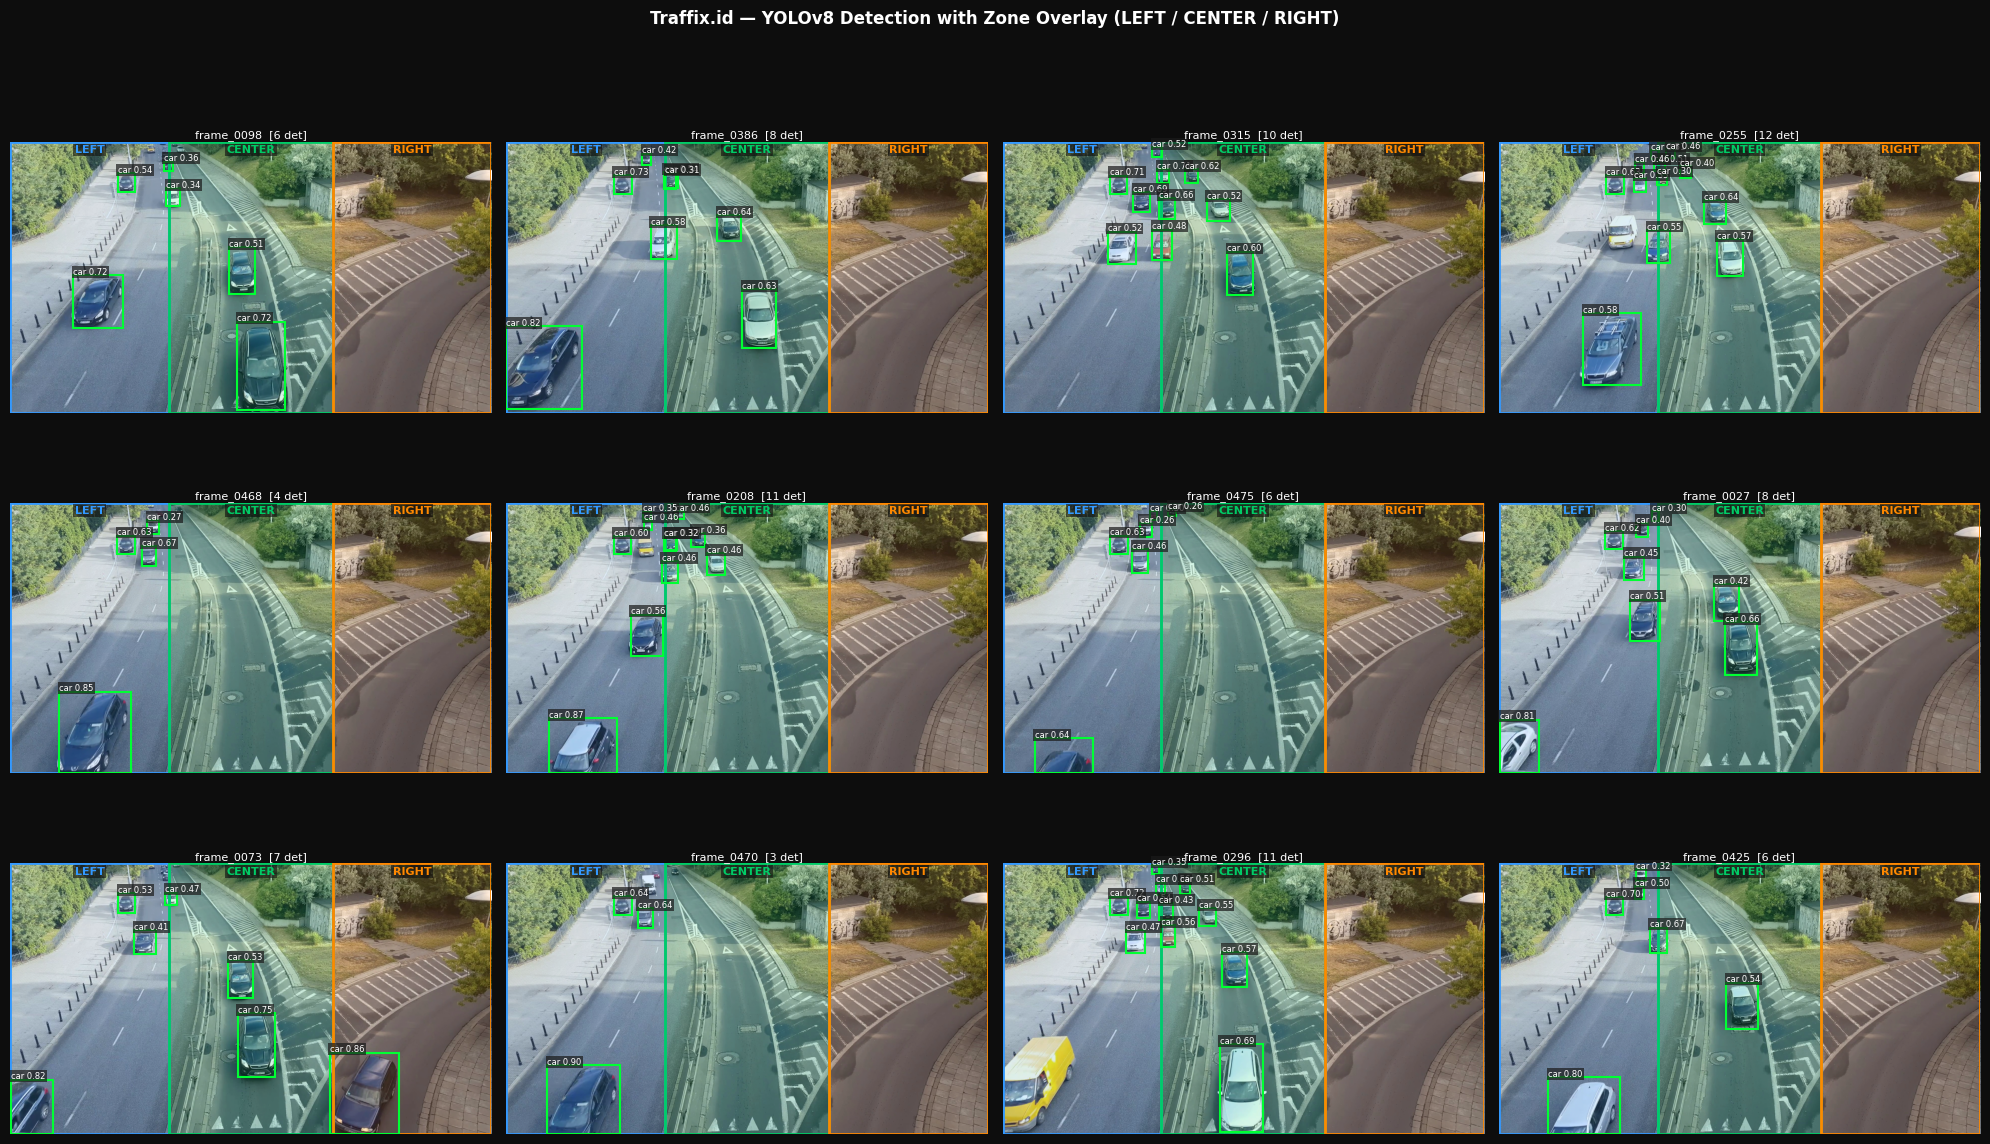

Saved: /content/detection_visualization.png


In [13]:
ZONE_COLORS_NORM = {
    "LEFT"  : (0.20, 0.60, 1.00, 0.15),   # blue
    "CENTER": (0.00, 0.80, 0.40, 0.15),   # green
    "RIGHT" : (1.00, 0.50, 0.10, 0.15),   # orange
}
ZONE_LABEL_COLORS = {
    "LEFT"  : "#3399FF",
    "CENTER": "#00CC66",
    "RIGHT" : "#FF8800",
}
BOX_COLOR = (0.00, 1.00, 0.20)   # bright green for detection boxes

N_SAMPLES = min(12, len(ALL_RESULTS))
sample_stems = random.sample(list(ALL_RESULTS.keys()), N_SAMPLES)

NCOLS = 4
NROWS = (N_SAMPLES + NCOLS - 1) // NCOLS

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 5, NROWS * 4))
axes = np.array(axes).flatten()

fig.patch.set_facecolor("#0D0D0D")

for idx, stem in enumerate(sample_stems):
    ax  = axes[idx]
    data = ALL_RESULTS[stem]
    img_w = data["img_w"]
    img_h = data["img_h"]

    img_bgr = cv2.imread(data["img_path"])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    # Zone overlays
    zone_bounds = {
        "LEFT"  : (0,                                  CONFIG["ZONE_LEFT_MAX"] * img_w),
        "CENTER": (CONFIG["ZONE_LEFT_MAX"] * img_w,   CONFIG["ZONE_CENTER_MAX"] * img_w),
        "RIGHT" : (CONFIG["ZONE_CENTER_MAX"] * img_w, img_w),
    }
    for zone, (zx1, zx2) in zone_bounds.items():
        rect = patches.Rectangle(
            (zx1, 0), zx2 - zx1, img_h,
            linewidth=2,
            edgecolor=ZONE_LABEL_COLORS[zone],
            facecolor=ZONE_COLORS_NORM[zone],
        )
        ax.add_patch(rect)
        ax.text(
            (zx1 + zx2) / 2, img_h * 0.04, zone,
            color=ZONE_LABEL_COLORS[zone],
            fontsize=8, fontweight="bold", ha="center",
            bbox=dict(facecolor="#0D0D0D", alpha=0.6, pad=1, edgecolor="none"),
        )

    # Bounding boxes
    for det in data["boxes"]:
        x1, y1, x2, y2 = det["box_xyxy"]
        cls_name = CLASS_NAMES[det["cls"]] if det["cls"] < len(CLASS_NAMES) else str(det["cls"])
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1.5, edgecolor=BOX_COLOR, facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 3, f"{cls_name} {det['conf']:.2f}",
            color="white", fontsize=6,
            bbox=dict(facecolor="#1A1A1A", alpha=0.7, pad=1, edgecolor="none"),
        )

    ax.set_title(
        f"{stem[:20]}  [{len(data['boxes'])} det]",
        color="white", fontsize=8, pad=3,
    )
    ax.axis("off")

# Hide unused axes
for i in range(N_SAMPLES, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "Traffix.id — YOLOv8 Detection with Zone Overlay (LEFT / CENTER / RIGHT)",
    color="white", fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout()

VIZ_PATH = Path(CONFIG["VIZ_PNG"])
plt.savefig(VIZ_PATH, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {VIZ_PATH.resolve()}")

## Section 14 — Traffic Feature Dashboard

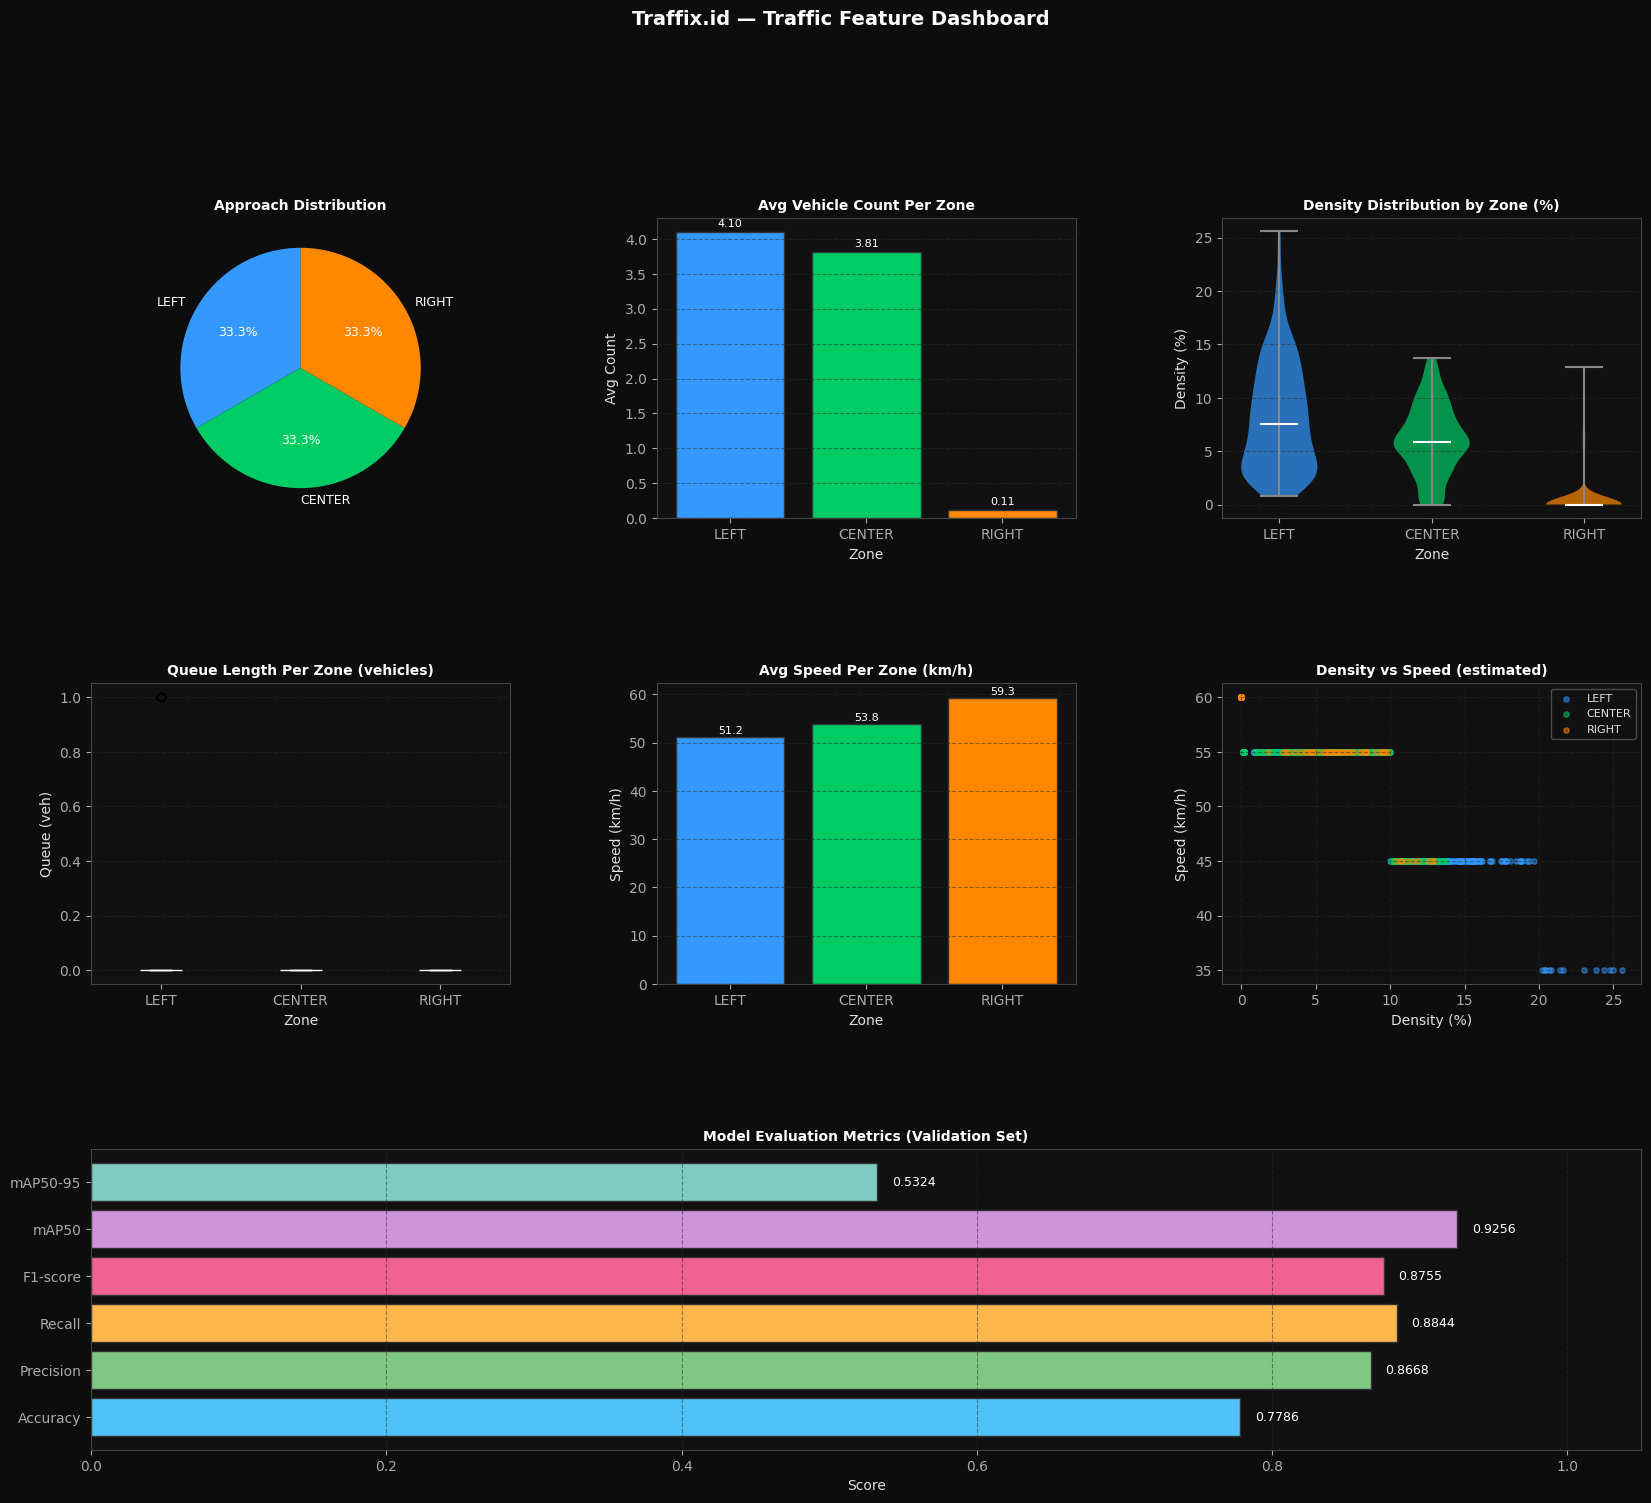

Saved: /content/traffic_feature_dashboard.png


In [14]:
matplotlib.rcParams.update({
    "axes.facecolor"  : "#111111",
    "figure.facecolor": "#0D0D0D",
    "axes.edgecolor"  : "#444444",
    "text.color"      : "#E0E0E0",
    "axes.labelcolor" : "#E0E0E0",
    "xtick.color"     : "#AAAAAA",
    "ytick.color"     : "#AAAAAA",
    "grid.color"      : "#2A2A2A",
    "grid.linestyle"  : "--",
    "grid.alpha"      : 0.5,
})

ZONE_PALETTE = {"LEFT": "#3399FF", "CENTER": "#00CC66", "RIGHT": "#FF8800"}

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor("#0D0D0D")
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# ── Panel 1: Approach Distribution (pie) ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
approach_counts = FEATURE_DF["approach"].value_counts().reindex(ZONE_LABELS)
colors_pie = [ZONE_PALETTE[z] for z in approach_counts.index]
ax1.pie(
    approach_counts,
    labels    = approach_counts.index,
    colors    = colors_pie,
    autopct   = "%1.1f%%",
    startangle= 90,
    textprops = {"color": "white", "fontsize": 9},
)
ax1.set_title("Approach Distribution", fontsize=10, fontweight="bold", color="white")

# ── Panel 2: Avg Vehicle Count Per Zone (bar) ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
mean_vc = FEATURE_DF.groupby("approach")["vehicle_count_1min"].mean().reindex(ZONE_LABELS)
bars = ax2.bar(mean_vc.index, mean_vc.values,
               color=[ZONE_PALETTE[z] for z in mean_vc.index], edgecolor="#333333")
ax2.set_title("Avg Vehicle Count Per Zone", fontsize=10, fontweight="bold", color="white")
ax2.set_xlabel("Zone");  ax2.set_ylabel("Avg Count")
ax2.grid(axis="y")
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8, color="white")

# ── Panel 3: Density Distribution (violin) ───────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
data_violin = [FEATURE_DF[FEATURE_DF["approach"] == z]["density_percent"].values for z in ZONE_LABELS]
parts = ax3.violinplot(data_violin, positions=range(3), showmedians=True)
for i, (pc, zone) in enumerate(zip(parts["bodies"], ZONE_LABELS)):
    pc.set_facecolor(ZONE_PALETTE[zone])
    pc.set_alpha(0.7)
parts["cmedians"].set_color("white")
parts["cbars"].set_color("#888888")
parts["cmins"].set_color("#888888")
parts["cmaxes"].set_color("#888888")
ax3.set_xticks(range(3)); ax3.set_xticklabels(ZONE_LABELS)
ax3.set_title("Density Distribution by Zone (%)", fontsize=10, fontweight="bold", color="white")
ax3.set_xlabel("Zone"); ax3.set_ylabel("Density (%)")
ax3.grid(axis="y")

# ── Panel 4: Queue Length Per Zone (box) ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
data_queue = [FEATURE_DF[FEATURE_DF["approach"] == z]["queue_length_veh"].values for z in ZONE_LABELS]
bp = ax4.boxplot(data_queue, labels=ZONE_LABELS, patch_artist=True, notch=False)
for patch, zone in zip(bp["boxes"], ZONE_LABELS):
    patch.set_facecolor(ZONE_PALETTE[zone]); patch.set_alpha(0.7)
for element in ["whiskers", "caps", "fliers", "medians"]:
    for line in bp[element]:
        line.set_color("white")
ax4.set_title("Queue Length Per Zone (vehicles)", fontsize=10, fontweight="bold", color="white")
ax4.set_xlabel("Zone"); ax4.set_ylabel("Queue (veh)")
ax4.grid(axis="y")

# ── Panel 5: Avg Speed Per Zone (bar) ────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
mean_speed = FEATURE_DF.groupby("approach")["avg_speed_kmh"].mean().reindex(ZONE_LABELS)
bars5 = ax5.bar(mean_speed.index, mean_speed.values,
                color=[ZONE_PALETTE[z] for z in mean_speed.index], edgecolor="#333333")
ax5.set_title("Avg Speed Per Zone (km/h)", fontsize=10, fontweight="bold", color="white")
ax5.set_xlabel("Zone"); ax5.set_ylabel("Speed (km/h)")
ax5.grid(axis="y")
for bar in bars5:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8, color="white")

# ── Panel 6: Density vs Speed (scatter) ──────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
for zone in ZONE_LABELS:
    sub = FEATURE_DF[FEATURE_DF["approach"] == zone]
    ax6.scatter(sub["density_percent"], sub["avg_speed_kmh"],
                c=ZONE_PALETTE[zone], label=zone, alpha=0.5, s=15)
ax6.set_title("Density vs Speed (estimated)", fontsize=10, fontweight="bold", color="white")
ax6.set_xlabel("Density (%)"); ax6.set_ylabel("Speed (km/h)")
ax6.legend(fontsize=8, framealpha=0.3)
ax6.grid()

# ── Panel 7: Model Metrics (horizontal bar) ───────────────────────────────────
ax7 = fig.add_subplot(gs[2, :])
metric_labels = ["Accuracy", "Precision", "Recall", "F1-score", "mAP50", "mAP50-95"]
metric_values = [
    METRIC_DICT["Accuracy"],
    METRIC_DICT["Precision"],
    METRIC_DICT["Recall"],
    METRIC_DICT["F1-score"],
    METRIC_DICT["mAP50"],
    METRIC_DICT["mAP50-95"],
]
bar_colors = ["#4FC3F7", "#81C784", "#FFB74D", "#F06292", "#CE93D8", "#80CBC4"]
hbars = ax7.barh(metric_labels, metric_values, color=bar_colors, edgecolor="#333333")
ax7.set_xlim(0, 1.05)
ax7.set_title("Model Evaluation Metrics (Validation Set)", fontsize=10, fontweight="bold", color="white")
ax7.set_xlabel("Score")
ax7.grid(axis="x")
for bar, val in zip(hbars, metric_values):
    ax7.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=9, color="white")

fig.suptitle(
    "Traffix.id — Traffic Feature Dashboard",
    color="white", fontsize=14, fontweight="bold", y=1.01,
)

DASH_PATH = Path(CONFIG["DASH_PNG"])
plt.savefig(DASH_PATH, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {DASH_PATH.resolve()}")

# Reset rcParams to default
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

## Section 15 — Summary of Outputs

In [15]:
outputs = {
    "traffic_features.csv"         : CONFIG["OUTPUT_CSV"],
    "detection_visualization.png"  : CONFIG["VIZ_PNG"],
    "traffic_feature_dashboard.png": CONFIG["DASH_PNG"],
    "best.pt"                      : str(BEST_PT),
}

print("=" * 60)
print("Traffix.id — Pipeline Complete")
print("=" * 60)
print()

print("Output Files")
print("-" * 60)
for label, path in outputs.items():
    p = Path(path)
    exists = "OK" if p.exists() else "MISSING"
    size   = f"{p.stat().st_size / 1024:.1f} KB" if p.exists() else "—"
    print(f"  {exists:8s}  {label:38s}  {size}")

print()
print("Model Metrics")
print("-" * 60)
for k, v in METRIC_DICT.items():
    print(f"  {k:12s}: {v}")

print()
print("Feature CSV Summary")
print("-" * 60)
print(f"  Rows          : {len(FEATURE_DF)}")
print(f"  Images        : {FEATURE_DF['image'].nunique()}")
print(f"  Zones         : {FEATURE_DF['approach'].unique().tolist()}")
print(f"  Avg Density   : {FEATURE_DF['density_percent'].mean():.2f}%")
print(f"  Avg Speed     : {FEATURE_DF['avg_speed_kmh'].mean():.1f} km/h  (estimated)")
print(f"  Avg Veh Count : {FEATURE_DF['vehicle_count_1min'].mean():.2f}")

print()
print("NOTE: avg_speed_kmh is a rule-based estimate, not ground-truth speed.")
print("=" * 60)

Traffix.id — Pipeline Complete

Output Files
------------------------------------------------------------
  OK        traffic_features.csv                    63.4 KB
  OK        detection_visualization.png             6068.1 KB
  OK        traffic_feature_dashboard.png           233.8 KB
  OK        best.pt                                 6075.2 KB

Model Metrics
------------------------------------------------------------
  TP          : 436
  FP          : 67
  FN          : 57
  Accuracy    : 0.7786
  Precision   : 0.8668
  Recall      : 0.8844
  F1-score    : 0.8755
  mAP50       : 0.9256
  mAP50-95    : 0.5324

Feature CSV Summary
------------------------------------------------------------
  Rows          : 1497
  Images        : 499
  Zones         : ['LEFT', 'CENTER', 'RIGHT']
  Avg Density   : 5.06%
  Avg Speed     : 54.8 km/h  (estimated)
  Avg Veh Count : 2.67

NOTE: avg_speed_kmh is a rule-based estimate, not ground-truth speed.
